# Домашнее задание 8-9

## Импорты, seed, устройство

In [1]:
import os
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms
import torch.nn as nn
from typing import Dict, List, Optional
import time
import json
import csv

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)

device: cpu
torch: 2.10.0


In [2]:
x = torch.tensor([1,2,3])
x_gpu = x.to(device)
print('x_gpu.device:', x_gpu.device)

z = torch.ones((2, 3), dtype=torch.float32, device=device)
print('z:', z, z.device, z.dtype)

x_gpu.device: cpu
z: tensor([[1., 1., 1.],
        [1., 1., 1.]]) cpu torch.float32


Убедились, что тензор располагается на cpu.

## Дополнительные функции

In [3]:
ARTIFACTS_DIR = "artifacts"
FIGURES_DIR   = os.path.join(ARTIFACTS_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

In [4]:
def plot_history(history: Dict[str, List[float]], title: str = "", save_path: str = None):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(list(epochs), history["train_loss"], label="train_loss")
    ax1.plot(list(epochs), history["val_loss"], label="val_loss")
    ax1.set_xlabel("epoch"); ax1.set_ylabel("loss")
    ax1.set_title("Loss"); ax1.legend()

    ax2.plot(list(epochs), history["train_acc"], label="train_acc")
    ax2.plot(list(epochs), history["val_acc"], label="val_acc")
    ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy")
    ax2.set_title("Accuracy"); ax2.legend()

    fig.suptitle(title)
    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=150)
    plt.show()


## Данные и DataLoader

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),  # mean/std для 1 канала
])

train_full = torchvision.datasets.EMNIST(
    root="./data", train=True, download=True, transform=transform, split="balanced"
)
test_ds = torchvision.datasets.EMNIST(
    root="./data", train=False, download=True, transform=transform, split="balanced"
)

In [6]:
BATCH_SIZE = 512
NUM_WORKERS = 4

# train/val split
val_ratio = 0.1
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

In [7]:
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

In [8]:
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype, x_batch.device)
print("y_batch:", y_batch.shape, y_batch.dtype, y_batch.device)

xmin, xmax = torch.aminmax(x_batch)   # диапазон значений
ymin, ymax = torch.aminmax(y_batch)

print("x:", float(xmin), float(xmax), "dtype:", x_batch.dtype)
print("y:", float(ymin), float(ymax), "dtype:", y_batch.dtype)

x_batch: torch.Size([512, 1, 28, 28]) torch.float32 cpu
y_batch: torch.Size([512]) torch.int64 cpu
x: -1.0 1.0 dtype: torch.float32
y: 0.0 46.0 dtype: torch.int64


Действительно, значения пикселей отнормированы от -1 до 1, а всего классов 47.

## Модель MLP и цикл обучения

In [9]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 47,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [10]:
def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()


def grad_global_norm(parameters) -> float:
    total_norm_sq = 0.0
    for p in parameters:
        if p.grad is None:
            continue
        param_norm = p.grad.data.norm(2).item()
        total_norm_sq += param_norm ** 2
    return np.sqrt(total_norm_sq)


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device = "cpu",
    max_grad_norm: Optional[float] = None,
    log_grad_norm: bool = False,
):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n = 0


    grad_norms_before = []
    grad_norms_after = []


    for x, y in loader:
        x = x.to(device)
        y = y.to(device)


        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)


        # иногда на очень агрессивных настройках бывает NaN – делаем мягкую защиту
        if not torch.isfinite(loss):
            continue


        loss.backward()


        if log_grad_norm:
            gn_before = grad_global_norm(model.parameters())
            grad_norms_before.append(gn_before)


        if max_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            if log_grad_norm:
                gn_after = grad_global_norm(model.parameters())
                grad_norms_after.append(gn_after)


        optimizer.step()


        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_from_logits(logits, y) * bs
        n += bs


    avg_loss = total_loss / max(1, n)
    avg_acc = total_acc / max(1, n)


    out = {"loss": float(avg_loss), "acc": float(avg_acc)}
    if log_grad_norm:
        out["grad_norm_before_mean"] = float(np.mean(grad_norms_before)) if grad_norms_before else None
        if max_grad_norm is not None:
            out["grad_norm_after_mean"] = float(np.mean(grad_norms_after)) if grad_norms_after else None
    return out


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, criterion: nn.Module, device: torch.device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        if not torch.isfinite(loss):
            continue
        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_from_logits(logits, y) * bs
        n += bs
    return {"loss": float(total_loss / max(1, n)), "acc": float(total_acc / max(1, n))}

In [11]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [12]:
def fit(model, train_loader, val_loader, optimizer, criterion, epochs=6, verbose=True, early_stopping=None):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr = train_one_epoch(model, train_loader, optimizer, criterion,device)
        va = evaluate(model, val_loader, criterion,device)

        tr_loss, tr_acc = tr['loss'], tr['acc']
        va_loss, va_acc = va['loss'], va['acc']

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0

        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not np.isfinite(tr_loss)) or (not np.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак слишком большого LR. Останавливаем эксперимент.")
            break

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

In [13]:
def make_optimizer(model, kind, lr, weight_decay=0.0, momentum=0.9):
    kind = kind.lower().strip()
    if kind == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if kind == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {kind}")

### Base mlp

In [14]:
criterion = nn.CrossEntropyLoss()
EPOCHS = 10

In [15]:
baseline_model = MLP().to(device)
baseline_opt = make_optimizer(baseline_model, kind="adam", lr=1e-3, weight_decay=0.0)

baseline_hist = fit(baseline_model, train_loader, val_loader, baseline_opt, criterion, epochs=EPOCHS)

Epoch 01/10 | train loss 1.6560, acc 0.552 | val loss 1.1680, acc 0.669 | 9.1s
Epoch 02/10 | train loss 0.9692, acc 0.714 | val loss 0.8646, acc 0.742 | 8.9s
Epoch 03/10 | train loss 0.7596, acc 0.768 | val loss 0.7184, acc 0.781 | 9.6s
Epoch 04/10 | train loss 0.6519, acc 0.796 | val loss 0.6436, acc 0.802 | 9.2s
Epoch 05/10 | train loss 0.5842, acc 0.812 | val loss 0.6026, acc 0.813 | 9.7s
Epoch 06/10 | train loss 0.5388, acc 0.825 | val loss 0.5911, acc 0.814 | 9.6s
Epoch 07/10 | train loss 0.5066, acc 0.833 | val loss 0.5500, acc 0.828 | 9.5s
Epoch 08/10 | train loss 0.4801, acc 0.841 | val loss 0.5337, acc 0.828 | 9.5s
Epoch 09/10 | train loss 0.4563, acc 0.847 | val loss 0.5311, acc 0.829 | 9.8s
Epoch 10/10 | train loss 0.4382, acc 0.850 | val loss 0.5139, acc 0.833 | 9.7s


### Dropout

In [16]:
dp_model = MLP(dropout_p=0.2,use_batchnorm=False).to(device)

dp_opt = make_optimizer(dp_model, kind="adam", lr=1e-3, weight_decay=0.0)

dp_hist = fit(dp_model, train_loader, val_loader, dp_opt, criterion, epochs=EPOCHS)

Epoch 01/10 | train loss 1.8327, acc 0.489 | val loss 1.0530, acc 0.696 | 9.2s
Epoch 02/10 | train loss 1.0716, acc 0.676 | val loss 0.8120, acc 0.755 | 9.4s
Epoch 03/10 | train loss 0.8923, acc 0.726 | val loss 0.6949, acc 0.785 | 9.9s
Epoch 04/10 | train loss 0.7934, acc 0.750 | val loss 0.6389, acc 0.805 | 8.9s
Epoch 05/10 | train loss 0.7382, acc 0.766 | val loss 0.5939, acc 0.817 | 8.9s
Epoch 06/10 | train loss 0.6939, acc 0.778 | val loss 0.5730, acc 0.819 | 8.9s
Epoch 07/10 | train loss 0.6648, acc 0.784 | val loss 0.5409, acc 0.827 | 8.9s
Epoch 08/10 | train loss 0.6425, acc 0.789 | val loss 0.5313, acc 0.830 | 8.9s
Epoch 09/10 | train loss 0.6198, acc 0.797 | val loss 0.5109, acc 0.835 | 8.9s
Epoch 10/10 | train loss 0.6018, acc 0.802 | val loss 0.5058, acc 0.837 | 8.9s


### BatchNorm

In [17]:
bn_model = MLP(dropout_p=0.0,use_batchnorm=True).to(device)
bn_opt = make_optimizer(bn_model, kind="adam", lr=1e-3, weight_decay=0.0)

bn_hist = fit(bn_model, train_loader, val_loader, bn_opt, criterion, epochs=EPOCHS)

Epoch 01/10 | train loss 1.3282, acc 0.690 | val loss 0.7682, acc 0.777 | 9.2s
Epoch 02/10 | train loss 0.5893, acc 0.818 | val loss 0.5607, acc 0.821 | 9.6s
Epoch 03/10 | train loss 0.4750, acc 0.845 | val loss 0.5304, acc 0.827 | 8.8s
Epoch 04/10 | train loss 0.4172, acc 0.859 | val loss 0.4795, acc 0.844 | 9.2s
Epoch 05/10 | train loss 0.3777, acc 0.870 | val loss 0.4808, acc 0.843 | 9.2s
Epoch 06/10 | train loss 0.3492, acc 0.876 | val loss 0.4728, acc 0.847 | 9.3s
Epoch 07/10 | train loss 0.3255, acc 0.883 | val loss 0.4765, acc 0.843 | 9.2s
Epoch 08/10 | train loss 0.3048, acc 0.891 | val loss 0.4702, acc 0.847 | 9.3s
Epoch 09/10 | train loss 0.2864, acc 0.895 | val loss 0.5211, acc 0.827 | 8.9s
Epoch 10/10 | train loss 0.2715, acc 0.901 | val loss 0.4753, acc 0.843 | 9.1s


### EarlyStopping

In [18]:
best_val_acc_e2 = max(dp_hist["val_acc"])
best_val_acc_e3 = max(bn_hist["val_acc"])

print(f"E2 (Dropout) best val_acc: {best_val_acc_e2:.4f}")
print(f"E3 (BatchNorm) best val_acc: {best_val_acc_e3:.4f}")

if best_val_acc_e2 >= best_val_acc_e3:
    print("→ Выбрана архитектура E2 (Dropout) для E4")
    best_kwargs = dict(dropout_p=0.2, use_batchnorm=False)
else:
    print("→ Выбрана архитектура E3 (BatchNorm) для E4")
    best_kwargs = dict(dropout_p=0.0, use_batchnorm=True)

E2 (Dropout) best val_acc: 0.8371
E3 (BatchNorm) best val_acc: 0.8467
→ Выбрана архитектура E3 (BatchNorm) для E4


Epoch 01/10 | train loss 1.3149, acc 0.691 | val loss 0.7480, acc 0.782 | 9.6s
Epoch 02/10 | train loss 0.5848, acc 0.820 | val loss 0.5904, acc 0.813 | 9.0s
Epoch 03/10 | train loss 0.4723, acc 0.845 | val loss 0.5160, acc 0.833 | 8.9s
Epoch 04/10 | train loss 0.4133, acc 0.860 | val loss 0.4979, acc 0.836 | 8.9s
Epoch 05/10 | train loss 0.3771, acc 0.870 | val loss 0.4685, acc 0.844 | 8.8s
Epoch 06/10 | train loss 0.3464, acc 0.879 | val loss 0.4688, acc 0.843 | 8.8s
Epoch 07/10 | train loss 0.3221, acc 0.885 | val loss 0.4606, acc 0.846 | 8.8s
Epoch 08/10 | train loss 0.3027, acc 0.892 | val loss 0.4645, acc 0.850 | 8.8s
Epoch 09/10 | train loss 0.2857, acc 0.896 | val loss 0.4642, acc 0.846 | 8.9s
Epoch 10/10 | train loss 0.2716, acc 0.900 | val loss 0.4905, acc 0.839 | 8.9s


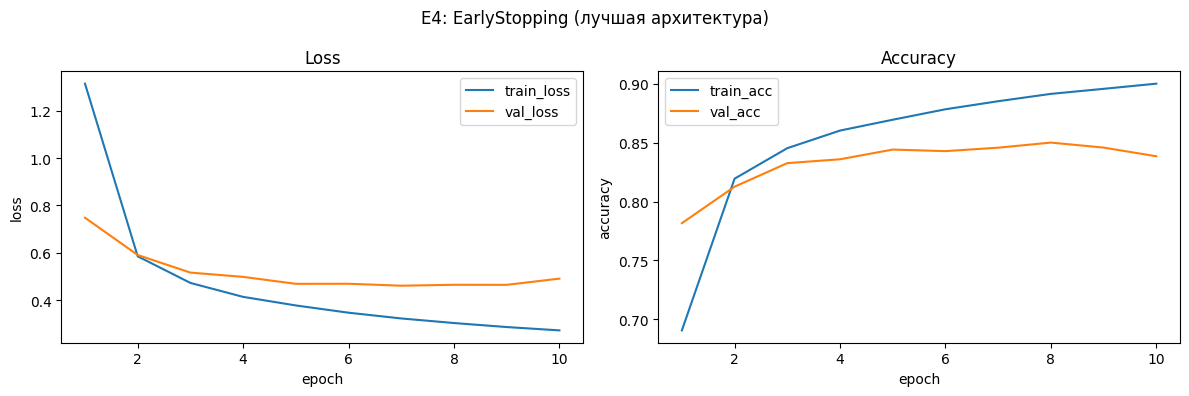

In [19]:
es = EarlyStopping(patience=4, min_delta=0.0005)
es_model = MLP(**best_kwargs).to(device)
es_opt   = make_optimizer(es_model, kind="adam", lr=1e-3, weight_decay=0.0)

es_hist = fit(
    es_model, train_loader, val_loader, es_opt, criterion,
    epochs=EPOCHS, early_stopping=es
)
plot_history(
    es_hist,
    title="E4: EarlyStopping (лучшая архитектура)",
    save_path=os.path.join(FIGURES_DIR, "curves_best.png")
)

## Сравнение моделей + итоговая оценка на test

In [20]:
def best_metrics(hist):
    best_epoch = int(np.argmax(hist["val_acc"]))
    return hist["val_acc"][best_epoch], hist["val_loss"][best_epoch], best_epoch + 1

e1_va, e1_vl, e1_ep = best_metrics(baseline_hist)
e2_va, e2_vl, e2_ep = best_metrics(dp_hist)
e3_va, e3_vl, e3_ep = best_metrics(bn_hist)
e4_va, e4_vl, e4_ep = best_metrics(es_hist)

results = {
    "E1": {"model": "baseline", "val_acc": e1_va, "val_loss": e1_vl, "epochs": e1_ep},
    "E2": {"model": "dropout",  "val_acc": e2_va, "val_loss": e2_vl, "epochs": e2_ep},
    "E3": {"model": "batchnorm","val_acc": e3_va, "val_loss": e3_vl, "epochs": e3_ep},
    "E4": {"model": "early_stop","val_acc": e4_va,"val_loss": e4_vl, "epochs": e4_ep},
}


In [21]:
print("\n=== Сравнение E1-E4 ===")
print(f"{'Exp':<5} {'Model':<12} {'val_acc':>8} {'val_loss':>9} {'epochs':>7}")
for exp_id, r in results.items():
    print(f"{exp_id:<5} {r['model']:<12} {r['val_acc']:>8.4f} {r['val_loss']:>9.4f} {r['epochs']:>7}")

test_metrics = evaluate(es_model, test_loader, criterion, device)
print(f"\nE4 test_acc={test_metrics['acc']:.4f}, test_loss={test_metrics['loss']:.4f}")

# --- Сохранить best_model.pt ---
torch.save(es_model.state_dict(), os.path.join(ARTIFACTS_DIR, "best_model.pt"))
print("best_model.pt сохранён")


=== Сравнение E1-E4 ===
Exp   Model         val_acc  val_loss  epochs
E1    baseline       0.8328    0.5139      10
E2    dropout        0.8371    0.5058      10
E3    batchnorm      0.8467    0.4702       8
E4    early_stop     0.8502    0.4645       8

E4 test_acc=0.8373, test_loss=0.5031
best_model.pt сохранён


In [22]:
# --- Сохранить best_config.json ---
best_config = {
    "dataset": "EMNIST balanced",
    "seed": SEED,
    "input_dim": 28 * 28,
    "hidden_dims": [256, 128],
    "num_classes": 47,
    "activation": "relu",
    **best_kwargs,
    "optimizer": "adam",
    "lr": 1e-3,
    "weight_decay": 0.0,
    "early_stopping_patience": 4,
    "early_stopping_min_delta": 0.0005,
    "epochs_trained": e4_ep,
    "best_val_accuracy": e4_va,
    "test_accuracy": test_metrics["acc"],
}
with open(os.path.join(ARTIFACTS_DIR, "best_config.json"), "w") as f:
    json.dump(best_config, f, indent=2)
print("best_config.json сохранён")

best_config.json сохранён


## LR, оптимизаторы, weight decay (обязательно)

In [26]:
def make_exp_model():
    return MLP(**best_kwargs).to(device)

LR_EPOCHS = 5

### Большой LR

In [27]:
o1_model = make_exp_model()
o1_opt   = make_optimizer(o1_model, kind="adam", lr=7e-1)
o1_hist  = fit(o1_model, train_loader, val_loader, o1_opt, criterion, epochs=LR_EPOCHS)

Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Users/polina/.local/share/uv/python/cpython-3.11.14-macos-aarch64-none/lib/python3.11/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/polina/.local/share/uv/python/cpython-3.11.14-macos-aarch64-none/lib/python3.11/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/polina/vscode/art_ing_course/.venv/lib/python3.11/site-packages/torch/multiprocessing/reductions.py", line 557, in rebuild_storage_filename
    storage = torch.UntypedStorage._new_shared_filename_cpu(manager, handle, size)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: Connection refused


KeyboardInterrupt: 

Из-за большого lr модель будто-бы перепрыгивает через оптимум, не может сойтись к минимуму

## Маленький LR

In [25]:
o2_model = make_exp_model()
o2_opt   = make_optimizer(o2_model, kind="adam", lr=1e-5)
o2_hist  = fit(o2_model, train_loader, val_loader, o2_opt, criterion, epochs=LR_EPOCHS)

Epoch 01/10 | train loss 3.7116, acc 0.075 | val loss 3.5031, acc 0.157 | 9.1s
Epoch 02/10 | train loss 3.3419, acc 0.246 | val loss 3.2022, acc 0.310 | 9.3s
Epoch 03/10 | train loss 3.0901, acc 0.366 | val loss 2.9892, acc 0.400 | 9.4s
Epoch 04/10 | train loss 2.9010, acc 0.441 | val loss 2.8233, acc 0.457 | 9.1s
Epoch 05/10 | train loss 2.7467, acc 0.489 | val loss 2.6827, acc 0.501 | 9.2s
Epoch 06/10 | train loss 2.6146, acc 0.525 | val loss 2.5598, acc 0.530 | 9.3s
Epoch 07/10 | train loss 2.4980, acc 0.551 | val loss 2.4535, acc 0.553 | 9.2s
Epoch 08/10 | train loss 2.3934, acc 0.571 | val loss 2.3532, acc 0.570 | 9.5s


Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Users/polina/.local/share/uv/python/cpython-3.11.14-macos-aarch64-none/lib/python3.11/multiprocessing/spawn.py", line 122, in spawn_main
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Users/polina/.local/share/uv/python/cpython-3.11.14-macos-aarch64-none/lib/python3.11/multiprocessing/spawn.py", line 122, in spawn_main
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Users/polina/.local/share/uv/python/cpython-3.11.14-macos-aarch64-none/lib/python3.11/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
    exitcode = _main(fd, parent_sentinel)
           exitcode = _main(fd, parent_sentinel)
                   ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^^^^^^^ ^ ^ ^ ^ ^ ^^^^^^^
  ^^^^^^^  File "/Users/polina/.local/share/uv/python/cpython-3.11.14-macos-aarch64-none/lib/python3.11/multiprocessing/spawn.py", line 132,

KeyboardInterrupt: 

из-за маленького lr модель не успевает обучиться. loss меняется слишком медленно.

## SGD+momentum + weight decay

In [ ]:
o3_model = make_exp_model()
o3_opt   = make_optimizer(o3_model, kind="sgd", lr=1e-2, momentum=0.9, weight_decay=1e-4)
o3_hist  = fit(o3_model, train_loader, val_loader, o3_opt, criterion, epochs=15)

### Сохранение артефактов

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, hist, label in [
    (axes[0], o1_hist, "O1: lr=1e-1 (слишком большой)"),
    (axes[1], o2_hist, "O2: lr=1e-5 (слишком маленький)"),
]:
    ep = range(1, len(hist["train_loss"]) + 1)
    ax.plot(list(ep), hist["train_loss"], label="train_loss")
    ax.plot(list(ep), hist["val_loss"],   label="val_loss")
    ax.set_title(label); ax.set_xlabel("epoch"); ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "curves_lr_extremes.png"), dpi=150)
plt.show()
print("curves_lr_extremes.png сохранён")

plot_history(o3_hist, title="O3: SGD momentum=0.9, wd=1e-4")